In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.markers as pltMarkers
from pastamarkers import markers

In [2]:
sources = pd.read_csv('/home/yuan/JWST/CentralDogma/2_Lust_/merged_5sigv2.csv')
candidates = pd.read_csv('/home/yuan/JWST/BD_image/All_candidates.csv')
candidates = candidates.loc[candidates['BDSED']==1]
Sonora_model = pd.read_csv('ABmag_table.csv')
ATMO_model = pd.read_csv('ATMO_mag_table.csv')
LOWZ_model = pd.read_csv('LOWZ_mag_table.csv')

# paper

In [24]:
mask = (sources['MAG_AUTO_F444W']>10)&(sources['MAG_AUTO_F277W']>10)&(sources['MAG_AUTO_F150W']>10)&(sources['MAG_AUTO_F115W']>10)
m444 = sources[mask]['MAG_AUTO_F444W']
m277 = sources[mask]['MAG_AUTO_F277W']
m150 = sources[mask]['MAG_AUTO_F150W']
m115 = sources[mask]['MAG_AUTO_F115W']
selection = (m277-m444>0.9)&(m115-m277+1<m277-m444)
S_model = lambda z: Sonora_model[(Sonora_model['log_g']==4.5)&(Sonora_model['[M/H]']==z)&(Sonora_model['Teff']<1310)]#&(Sonora_model['Teff']>490)]
A_model = lambda z: ATMO_model[(ATMO_model['log_g']==4.5)&(ATMO_model['[M/H]']==z)]#&(ATMO_model['Teff']>490)]
L_model = lambda z, CO, Kzz: LOWZ_model[(LOWZ_model['logg']==4.5)&(LOWZ_model['logZ']==z)&(LOWZ_model['CtoO']==CO)&(LOWZ_model['logKzz']==Kzz)&(LOWZ_model['Teff']<1310)]
# (Sonora_model['log_g']==4.5)&
# (ATMO_model['log_g']==4.5)&
# (LOWZ_model['logg']==4.5)&

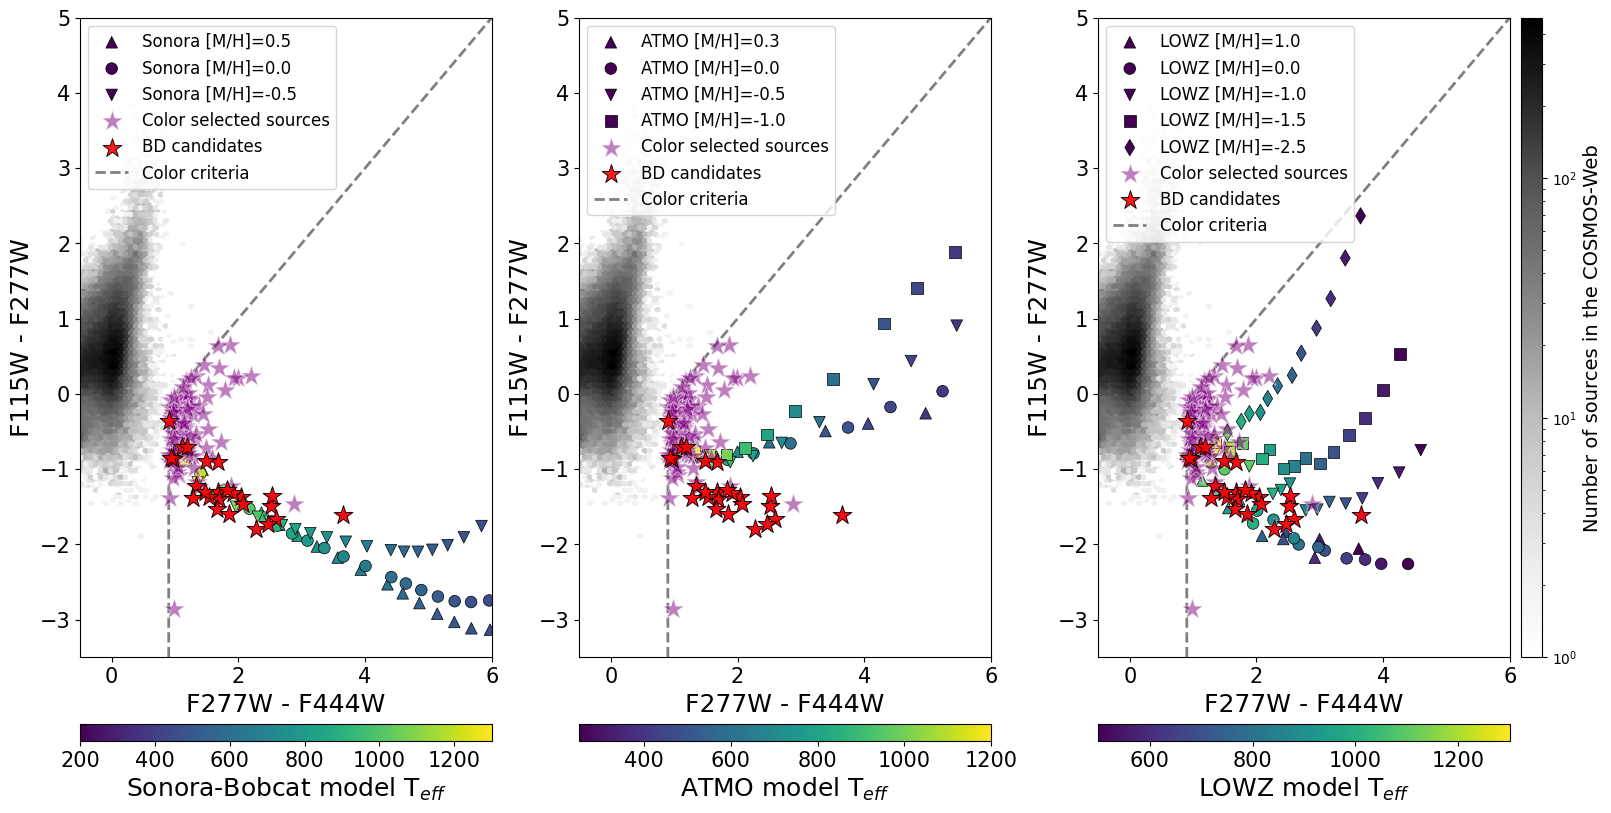

In [29]:
fig, axs = plt.subplots(1, 3, figsize=(16,8), layout='constrained')
pltlim = [6, -3.5]

ax = axs[0]
for z, marker in zip([0.5, 0.0, -0.5], ['^', 'o', 'v']):
    sc = ax.scatter(
        S_model(z)['F277W']-S_model(z)['F444W'], S_model(z)['F115W']-S_model(z)['F277W'],
        label=f'Sonora [M/H]={z}', c = S_model(z)['Teff'],
        s=70, marker=marker, cmap='viridis', edgecolors='k', linewidth=0.5
    )
cbar1 = fig.colorbar(sc, ax=ax, pad = 0.01, aspect=25, orientation='horizontal')
cbar1.set_label('Sonora-Bobcat model T$_{eff}$', fontsize=18)
cbar1.ax.tick_params(labelsize=15)

ax = axs[1]
for z, marker in zip([0.3, 0.0, -0.5, -1.0], ['^', 'o', 'v', 's']):
    ac = ax.scatter(
        A_model(z)['F277W']-A_model(z)['F444W'], A_model(z)['F115W']-A_model(z)['F277W'],
        label=f'ATMO [M/H]={z}', c = A_model(z)['Teff'],
        s=70, marker=marker, cmap='viridis', edgecolors='k', linewidth=0.5
    )
cbar2 = fig.colorbar(ac, ax=ax, pad = 0.01, aspect=25, orientation='horizontal')
cbar2.set_label('ATMO model T$_{eff}$', fontsize=18)
cbar2.ax.tick_params(labelsize=15)

ax = axs[2]
CtoO = 0.55
Kzz = 2
for z, marker in zip([1.0, 0.0, -1.0, -1.5, -2.5], ['^', 'o', 'v', 's', 'd']):
    lc = ax.scatter(
        L_model(z, CtoO, Kzz)['F277W']-L_model(z, CtoO, Kzz)['F444W'],
        L_model(z, CtoO, Kzz)['F115W']-L_model(z, CtoO, Kzz)['F277W'],
        label=f'LOWZ [M/H]={z}', c = L_model(z, CtoO, Kzz)['Teff'], 
        s=70, marker=marker, cmap='viridis', edgecolors='k', linewidth=0.5
    )
cbar3 = fig.colorbar(lc, ax=ax, pad = 0.01, aspect=25, orientation='horizontal')
cbar3.set_label('LOWZ model T$_{eff}$', fontsize=18)
cbar3.ax.tick_params(labelsize=15)

model_names = ['Sonora-Bobcat', 'ATMO', 'LOWZ']
for ax in axs:
    hb = ax.hexbin(
        m277-m444, m115-m277, gridsize=160, cmap='Greys', bins='log', zorder=0
    )
    ax.scatter(
        (m277-m444)[selection], (m115-m277)[selection],
        s=250, color='purple', edgecolors='w', linewidth=0.7, marker='*', label='Color selected sources',
        # s=300, edgecolors='gold', marker=t, label='Selected sources',
        alpha=0.5, zorder=10
    )
    ax.scatter(
        candidates['MAG_AUTO_F277W']-candidates['MAG_AUTO_F444W'], candidates['MAG_AUTO_F115W']-candidates['MAG_AUTO_F277W'],
        s=200, color='red', edgecolors='k', linewidth=0.7, marker='*', label='BD candidates',
        alpha=0.9, zorder=10
    )
    ax.plot([0.9, 0.9, 7], [pltlim[1], -0.1, pltlim[0]], c='grey', ls='--', lw=2, label='Color criteria')
    ax.set_xlabel('F277W - F444W', fontsize=18)
    ax.set_ylabel('F115W - F277W', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.set_xlim(-0.5, pltlim[0])
    ax.set_ylim(pltlim[1], 5)
    # ax.set_title(model_names.pop(0), fontsize=20)
    ax.legend(loc = 'upper left', fontsize=12)

cbar = fig.colorbar(hb, ax=ax, pad = 0.01, aspect=30)
cbar.set_label('Number of sources in the COSMOS-Web', fontsize=14)

# plt.tight_layout()
plt.show()

In [31]:
(71492/(3.08e13))**2

5.387824742789678e-18

# Spaghetti

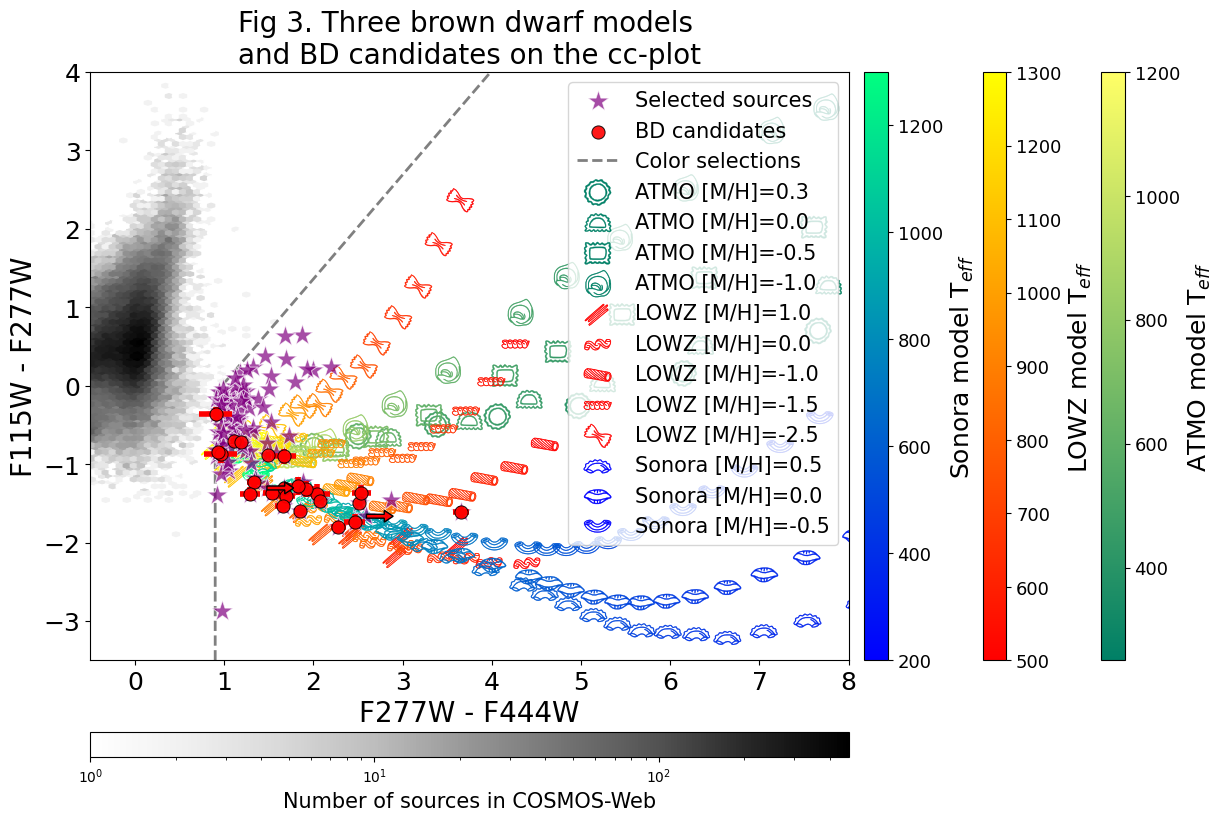

In [26]:
mask = (sources['MAG_AUTO_F444W']>10)&(sources['MAG_AUTO_F277W']>10)&(sources['MAG_AUTO_F150W']>10)&(sources['MAG_AUTO_F115W']>10)
m444 = sources[mask]['MAG_AUTO_F444W']
m277 = sources[mask]['MAG_AUTO_F277W']
m150 = sources[mask]['MAG_AUTO_F150W']
m115 = sources[mask]['MAG_AUTO_F115W']

candi_mask = (candidates['MAGERR_AUTO_F444W']>0)&(candidates['MAGERR_AUTO_F277W']>0)&(candidates['MAGERR_AUTO_F115W']>0)
detected = candidates.loc[candi_mask]
upperlimit = candidates.loc[(candidates['MAGERR_AUTO_F444W']<0)|(candidates['MAGERR_AUTO_F277W']<0)|(candidates['MAGERR_AUTO_F115W']<0)]

selection = (m277-m444>0.9)&(m115-m277+1<m277-m444)
pltlim = [8, -3.5]

fig, ax = plt.subplots(figsize=(12,8), layout='constrained')

hb = ax.hexbin(
    m277-m444, m115-m277,
    gridsize=160, cmap='Greys', bins='log'
)
cbar = fig.colorbar(hb, ax=ax, pad = 0.01, aspect=30, orientation='horizontal')
cbar.set_label('Number of sources in COSMOS-Web', fontsize=15)

ax.scatter(
    (m277-m444)[selection], (m115-m277)[selection],
    s=250, color='purple', edgecolors='w', linewidth=0.7, marker='*', label='Selected sources',
    # s=300, edgecolors='gold', marker=t, label='Selected sources',
    alpha=0.7, zorder=10
)

ax.scatter(
    detected['MAG_AUTO_F277W']-detected['MAG_AUTO_F444W'], 
    detected['MAG_AUTO_F115W']-detected['MAG_AUTO_F277W'],
    s=90, color='red', edgecolors='k', linewidth=0.7, marker='o', label='BD candidates',
    alpha=0.9, zorder=15
)
ax.errorbar(
    detected['MAG_AUTO_F277W']-detected['MAG_AUTO_F444W'],
    detected['MAG_AUTO_F115W']-detected['MAG_AUTO_F277W'],
    np.sqrt(detected['MAGERR_AUTO_F277W']**2+detected['MAGERR_AUTO_F444W']**2), 
    np.sqrt(detected['MAGERR_AUTO_F115W']**2+detected['MAGERR_AUTO_F277W']**2),
    color='red', ls='', lw=4, fmt='.', zorder=14
)

# Adding arrows for non-detected candidates
nondetect_115 = upperlimit.loc[upperlimit['MAGERR_AUTO_F115W'] < 0]
nondetect_277 = upperlimit.loc[upperlimit['MAGERR_AUTO_F277W'] < 0]
nondetect_444 = upperlimit.loc[upperlimit['MAGERR_AUTO_F444W'] < 0]

for idx, row in nondetect_115.iterrows():
    ax.arrow(row['MAG_AUTO_F277W'] - row['MAG_AUTO_F444W'], row['MAG_AUTO_F115W'] - row['MAG_AUTO_F277W'],
            0, 0.5, head_width=0.15, head_length=0.1, fc='red', ec='k', zorder=20, width=0.05)

for idx, row in nondetect_277.iterrows():
    ax.arrow(row['MAG_AUTO_F277W'] - row['MAG_AUTO_F444W'], row['MAG_AUTO_F115W'] - row['MAG_AUTO_F277W'],
            0.2, 0, head_width=0.15, head_length=0.1, fc='red', ec='k', zorder=20, width=0.05)

for idx, row in nondetect_444.iterrows():
    ax.arrow(row['MAG_AUTO_F277W'] - row['MAG_AUTO_F444W'], row['MAG_AUTO_F115W'] - row['MAG_AUTO_F277W'],
            1, 0, head_width=0.15, head_length=0.1, fc='red', ec='k', zorder=20, width=0.05)

ax.plot([0.9, 0.9, 7], [pltlim[1], -0.1, pltlim[0]], c='grey', ls='--', lw=2, label='Color selections')

S_model = lambda z: Sonora_model[(Sonora_model['log_g']==4.5)&(Sonora_model['[M/H]']==z)&(Sonora_model['Teff']<1310)]#&(Sonora_model['Teff']>490)]
A_model = lambda z: ATMO_model[(ATMO_model['log_g']==4.5)&(ATMO_model['[M/H]']==z)]#&(ATMO_model['Teff']>490)]
L_model = lambda z, CO, Kzz: LOWZ_model[(LOWZ_model['logg']==4.5)&(LOWZ_model['logZ']==z)&(LOWZ_model['CtoO']==CO)&(LOWZ_model['logKzz']==Kzz)&(LOWZ_model['Teff']<1310)]
# (Sonora_model['log_g']==4.5)&
# (ATMO_model['log_g']==4.5)&
# (LOWZ_model['logg']==4.5)&

# for z, marker in zip([0.3, 0.0, -0.5, -1.0], ['^', 'o', 'v', 's']):
for z, marker in zip([0.3, 0.0, -0.5, -1.0], [markers.soli, markers.mezzelune, markers.ravioli, markers.tortellini]):
    ac = ax.scatter(
        A_model(z)['F277W']-A_model(z)['F444W'], A_model(z)['F115W']-A_model(z)['F277W'],
        label=f'ATMO [M/H]={z}', c = A_model(z)['Teff'],
        # s=30, marker=marker, cmap='Greens', edgecolors='#20EF20',# alpha=0.5
        s=400, marker=marker, cmap='summer', linewidths=0.3
    )
cbar2 = fig.colorbar(ac, ax=ax, pad = 0.01, aspect=25)
cbar2.set_label('ATMO model T$_{eff}$', fontsize=18)
cbar2.ax.tick_params(labelsize=13)

def RM(angle, marker):
    t = pltMarkers.MarkerStyle(marker=marker)
    t._transform = t.get_transform().rotate_deg(angle)
    return t

CtoO = 0.55
Kzz = 2
# for z, marker in zip([1.0, 0.0, -1.0, -1.5, -2.5], ['^', 'o', 'v', 's', 'd']):
for z, marker in zip([1.0, 0.0, -1.0, -1.5, -2.5], [RM(40, markers.spaghetti), RM(10, markers.cavatappi), RM(-10, markers.tortiglioni), markers.fusilli, RM(-30, markers.farfalle)]):
    lc = ax.scatter(
        L_model(z, CtoO, Kzz)['F277W']-L_model(z, CtoO, Kzz)['F444W'],
        L_model(z, CtoO, Kzz)['F115W']-L_model(z, CtoO, Kzz)['F277W'],
        label=f'LOWZ [M/H]={z}', c = L_model(z, CtoO, Kzz)['Teff'], 
        # s=40, marker=marker, cmap='Oranges', edgecolors='orange',# alpha=0.4
        s=400, marker=marker, cmap='autumn', linewidths=0.3
    )
cbar3 = fig.colorbar(lc, ax=ax, pad = 0.01, aspect=25)
cbar3.set_label('LOWZ model T$_{eff}$', fontsize=18)
cbar3.ax.tick_params(labelsize=13)

# for z, marker in zip([0.5, 0.0, -0.5], ['^', 'o', 'v']):
for z, marker in zip([0.5, 0.0, -0.5], [markers.creste, markers.conchiglie, markers.maccheroni]):
    sc = ax.scatter(
        S_model(z)['F277W']-S_model(z)['F444W'], S_model(z)['F115W']-S_model(z)['F277W'],
        label=f'Sonora [M/H]={z}', c = S_model(z)['Teff'],
        # s=50, marker=marker, cmap='Purples', edgecolors='#EEAAFF',# alpha=0.5
        s=400, marker=marker, cmap='winter', linewidths=0.3
    )
cbar1 = fig.colorbar(sc, ax=ax, pad = 0.01, aspect=25)
cbar1.set_label('Sonora model T$_{eff}$', fontsize=18)
cbar1.ax.tick_params(labelsize=13)

ax.set_xlabel('F277W - F444W', fontsize=20)
ax.set_ylabel('F115W - F277W', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)

ax.set_xlim(-0.5, pltlim[0])
ax.set_ylim(pltlim[1], 4)

ax.legend(loc = 'upper right', fontsize=15)

# plt.title(f'Models on the cc-plot, {len(m444[selection])} sources pass the selection', fontsize=20)
# plt.title(f'Models on the cc-plot, LOWZ C/O={CtoO}, logKzz={Kzz}', fontsize=20)
plt.title('Fig 3. Three brown dwarf models \nand BD candidates on the cc-plot', fontsize=20)
# plt.tight_layout()
plt.show()

# LOWZ

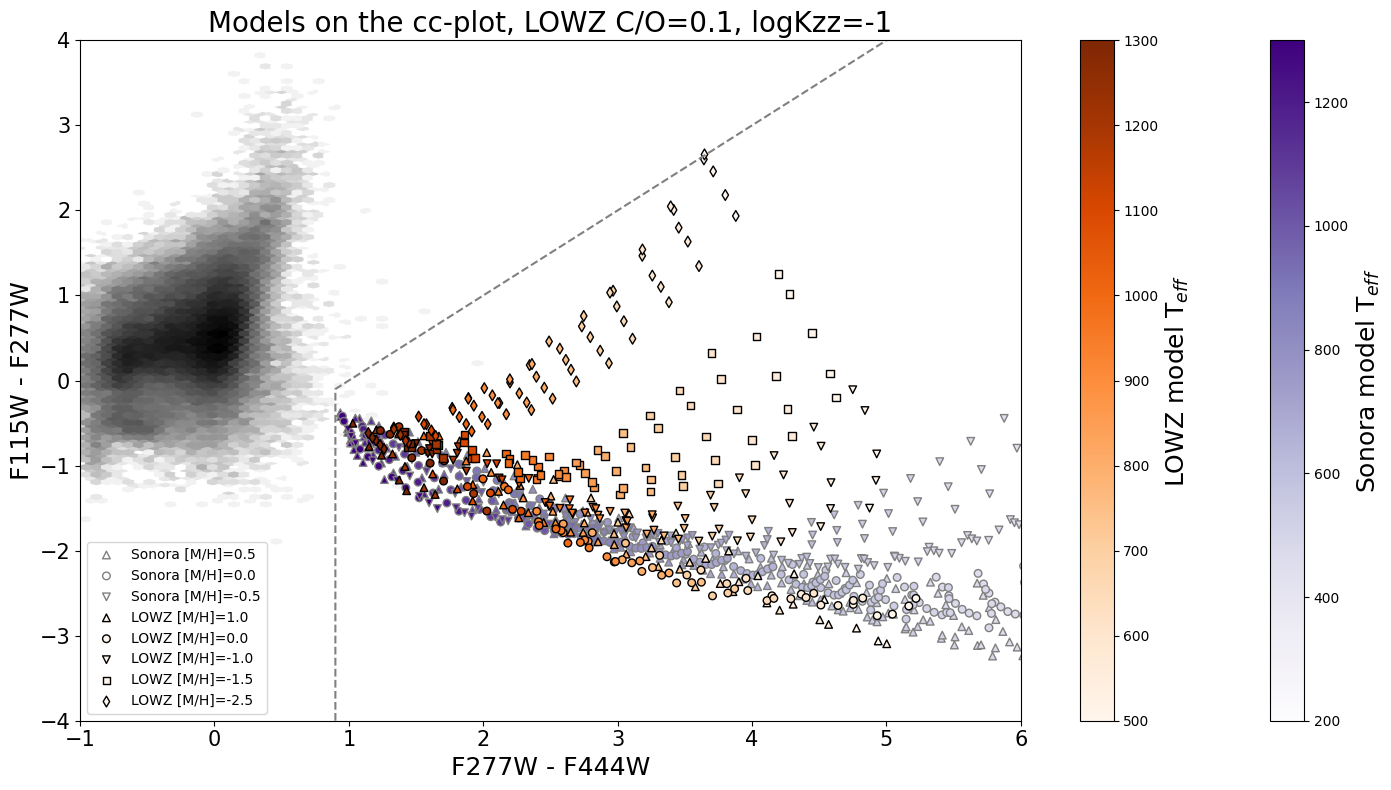

In [31]:
mask = (sources['MAG_AUTO_F444W']>10)&(sources['MAG_AUTO_F277W']>10)&(sources['MAG_AUTO_F150W']>10)&(sources['MAG_AUTO_F115W']>10)
m444 = sources[mask]['MAG_AUTO_F444W']
m277 = sources[mask]['MAG_AUTO_F277W']
m150 = sources[mask]['MAG_AUTO_F150W']
m115 = sources[mask]['MAG_AUTO_F115W']

# selection = (m277-m444>1.1)&(m115-m277<-0.8)
# selection = (m277-m444>1)
selection = (m277-m444>0.9)&(m115-m277+1<m277-m444)
pltlim = [6, -4]

fig, ax = plt.subplots(figsize=(15,8))

hb = ax.hexbin(
    m277-m444, m115-m277,
    gridsize=160, cmap='Greys', bins='log'
)
# ax.scatter(
#     (m277-m444)[selection], (m115-m277)[selection],
#     s=50, color='red', marker='*', label='Selected sources', alpha=0.5, zorder=10
# )
# ax.plot([1.1, 1.1, pltlim[0]], [pltlim[1], -0.8, -0.8], c='grey', ls='--')
# ax.plot([1, 1], [pltlim[1], pltlim[0]], c='grey', ls='--')
ax.plot([0.9, 0.9, 7], [pltlim[1], -0.1, pltlim[0]], c='grey', ls='--')

S_model = lambda z: Sonora_model[(Sonora_model['Z']==z)&(Sonora_model['Teff']<1310)]
A_model = lambda z: ATMO_model[(ATMO_model['[M/H]']==z)]
L_model = lambda z, CO, Kzz: LOWZ_model[(LOWZ_model['logZ']==z)&(LOWZ_model['CtoO']==CO)&(LOWZ_model['logKzz']==Kzz)&(LOWZ_model['Teff']<1310)]
# (ATMO_model['log_g']==5)&
# (Sonora_model['log(g)']==5)&


for z, marker in zip([0.5, 0.0, -0.5], ['^', 'o', 'v']):
    sc = ax.scatter(
        S_model(z)['F277W']-S_model(z)['F444W'], S_model(z)['F115W']-S_model(z)['F277W'],
        label=f'Sonora [M/H]={z}', c = S_model(z)['Teff'], cmap='Purples',
        s=30, marker=marker, edgecolors='grey'
    )
cbar1 = fig.colorbar(sc, ax=ax, pad = 0.01)
cbar1.set_label('Sonora model T$_{eff}$', fontsize=18)

# for z, marker in zip([-1.0, -0.5, 0.0, 0.3], ['s', 'v', 'o', '^']):
#     ac = ax.scatter(
#         A_model(z)['F277W']-A_model(z)['F444W'], A_model(z)['F115W']-A_model(z)['F277W'],
#         label=f'ATMO [M/H]={z}', c = A_model(z)['Teff'], cmap='Greens', s=20, marker=marker
#     )
# cbar2 = fig.colorbar(ac, ax=ax, pad = 0.03)
# cbar2.set_label('ATMO model T$_{eff}$', fontsize=18)

CtoO = 0.1
Kzz = -1
for z, marker in zip([1.0, 0.0, -1.0, -1.5, -2.5], ['^', 'o', 'v', 's', 'd']):
    lc = ax.scatter(
        L_model(z, CtoO, Kzz)['F277W']-L_model(z, CtoO, Kzz)['F444W'],
        L_model(z, CtoO, Kzz)['F115W']-L_model(z, CtoO, Kzz)['F277W'],
        label=f'LOWZ [M/H]={z}', c = L_model(z, CtoO, Kzz)['Teff'], cmap='Oranges',
        s=30, marker=marker, edgecolors='black'
    )
cbar3 = fig.colorbar(lc, ax=ax, pad = 0.05)
cbar3.set_label('LOWZ model T$_{eff}$', fontsize=18)

ax.set_xlabel('F277W - F444W', fontsize=18)
ax.set_ylabel('F115W - F277W', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=15)

ax.set_xlim(-1, pltlim[0])
ax.set_ylim(pltlim[1], 4)

ax.legend(loc = 'lower left', fontsize=10)

# plt.title(f'Models on the cc-plot, {len(m444[selection])} sources pass the selection', fontsize=20)
plt.title(f'Models on the cc-plot, LOWZ C/O={CtoO}, logKzz={Kzz}', fontsize=20)
plt.tight_layout()
plt.show()

# ATMO

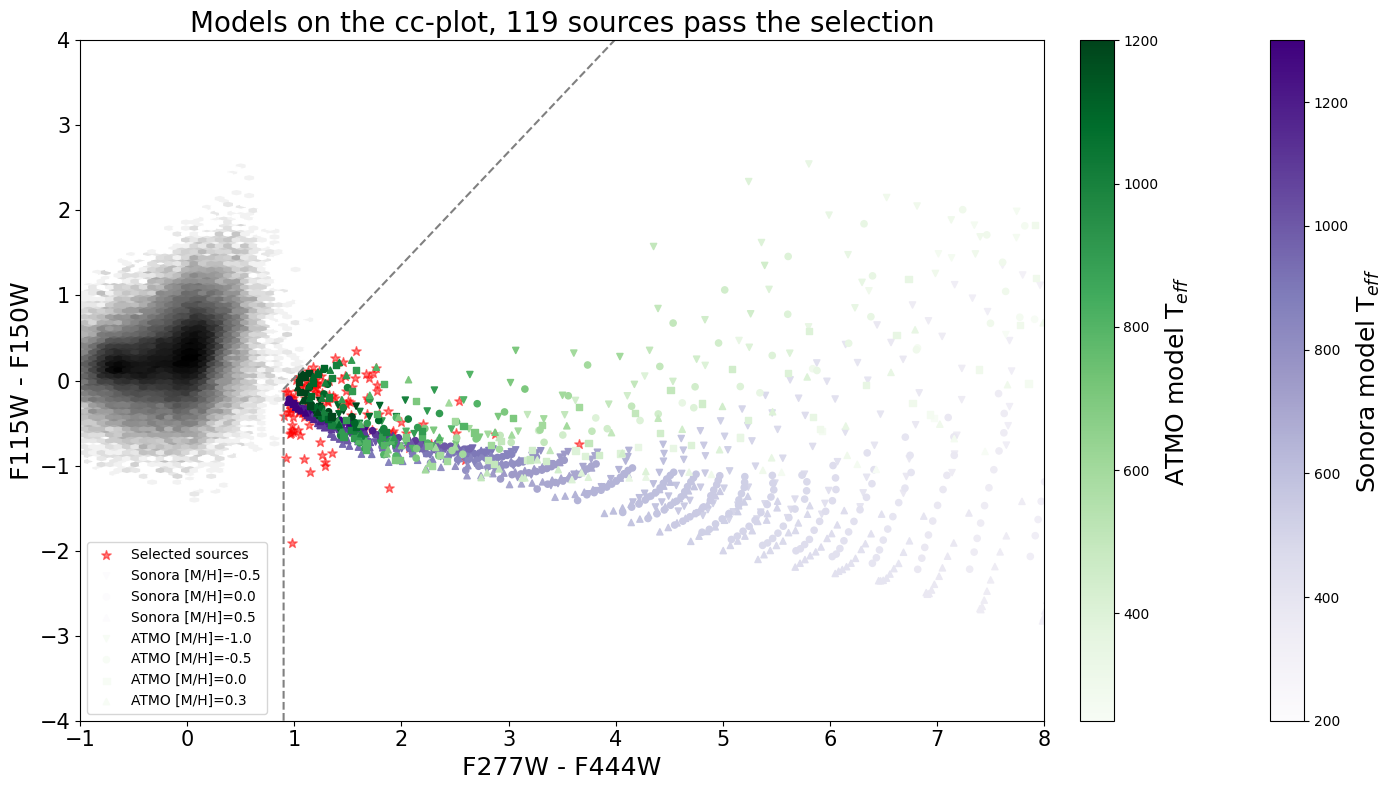

In [5]:
mask = (sources['MAG_AUTO_F444W']>10)&(sources['MAG_AUTO_F277W']>10)&(sources['MAG_AUTO_F150W']>10)&(sources['MAG_AUTO_F115W']>10)
m444 = sources[mask]['MAG_AUTO_F444W']
m277 = sources[mask]['MAG_AUTO_F277W']
m150 = sources[mask]['MAG_AUTO_F150W']
m115 = sources[mask]['MAG_AUTO_F115W']

# selection = (m277-m444>1.1)&(m115-m277<-0.8)
# selection = (m277-m444>1)
selection = (m277-m444>0.9)&(m115-m150+1<m277-m444)
pltlim = [8, -4]

fig, ax = plt.subplots(figsize=(15,8))

hb = ax.hexbin(
    m277-m444, m115-m150,
    gridsize=160, cmap='Greys', bins='log'
)
ax.scatter(
    (m277-m444)[selection], (m115-m150)[selection],
    s=50, color='red', marker='*', label='Selected sources', alpha=0.5
)
# ax.plot([1.1, 1.1, pltlim[0]], [pltlim[1], -0.8, -0.8], c='grey', ls='--')
# ax.plot([1, 1], [pltlim[1], pltlim[0]], c='grey', ls='--')
ax.plot([0.9, 0.9, 7], [pltlim[1], -0.1, pltlim[0]], c='grey', ls='--')

S_model = lambda z: Sonora_model[(Sonora_model['Z']==z)&(Sonora_model['Teff']<1310)]
A_model = lambda z: ATMO_model[(ATMO_model['[M/H]']==z)]
# (ATMO_model['log_g']==5)&
# (Sonora_model['log(g)']==5)&

for z, marker in zip([-0.5, 0.0, 0.5], ['v', 'o', '^']):
    sc = ax.scatter(
        S_model(z)['F277W']-S_model(z)['F444W'], S_model(z)['F115W']-S_model(z)['F150W'],
        label=f'Sonora [M/H]={z}', c = S_model(z)['Teff'], cmap='Purples', s=20, marker=marker
    )
cbar1 = fig.colorbar(sc, ax=ax, pad = 0.01)
cbar1.set_label('Sonora model T$_{eff}$', fontsize=18)

for z, marker in zip([-1.0, -0.5, 0.0, 0.3], ['v', 'o', 's', '^']):
    ac = ax.scatter(
        A_model(z)['F277W']-A_model(z)['F444W'], A_model(z)['F115W']-A_model(z)['F150W'],
        label=f'ATMO [M/H]={z}', c = A_model(z)['Teff'], cmap='Greens', s=20, marker=marker
    )
cbar2 = fig.colorbar(ac, ax=ax, pad = 0.03)
cbar2.set_label('ATMO model T$_{eff}$', fontsize=18)

ax.set_xlabel('F277W - F444W', fontsize=18)
ax.set_ylabel('F115W - F150W', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=15)

ax.set_xlim(-1, pltlim[0])
ax.set_ylim(pltlim[1], 4)

ax.legend(loc = 'lower left', fontsize=10)

plt.title(f'Models on the cc-plot, {len(m444[selection])} sources pass the selection', fontsize=20)
plt.tight_layout()
plt.show()

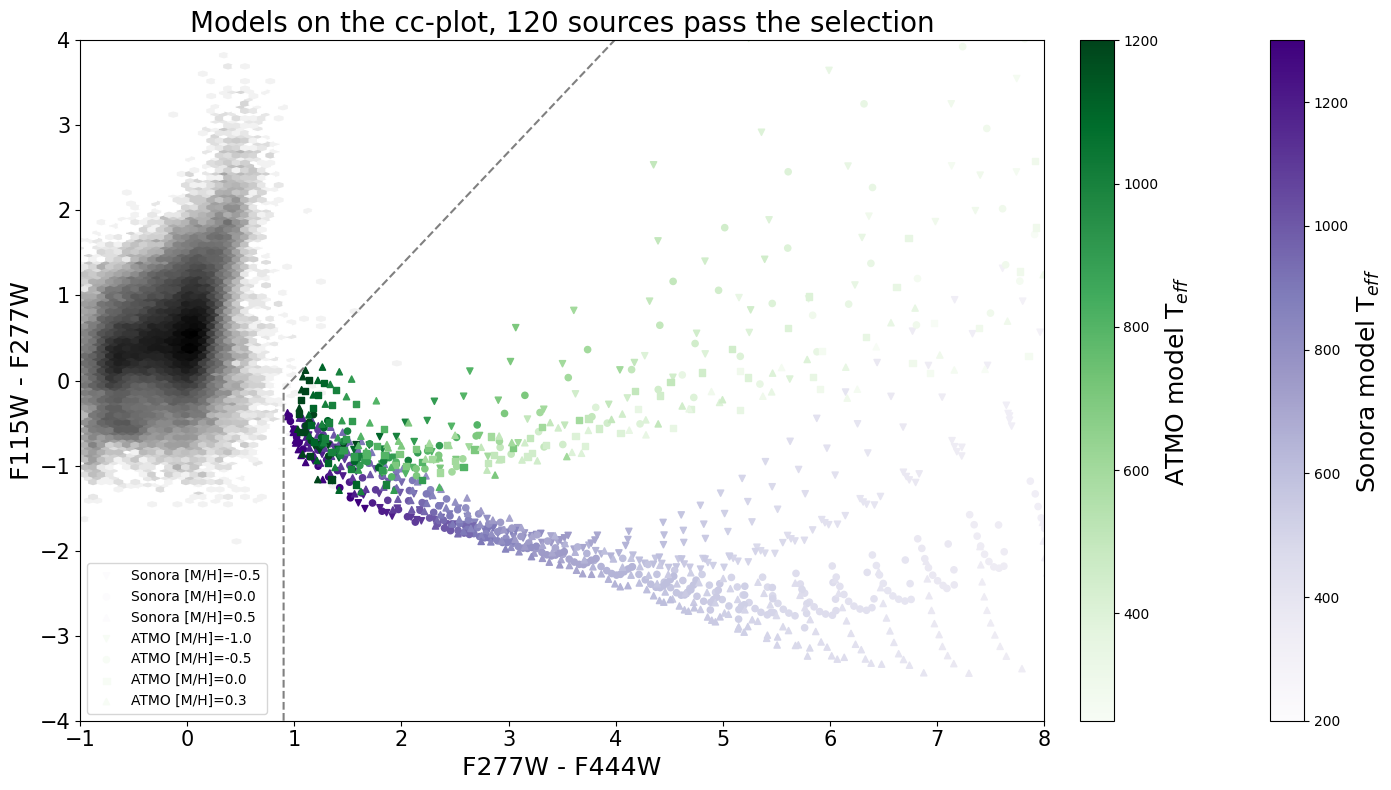

In [4]:
mask = (sources['MAG_AUTO_F444W']>10)&(sources['MAG_AUTO_F277W']>10)&(sources['MAG_AUTO_F150W']>10)&(sources['MAG_AUTO_F115W']>10)
m444 = sources[mask]['MAG_AUTO_F444W']
m277 = sources[mask]['MAG_AUTO_F277W']
m150 = sources[mask]['MAG_AUTO_F150W']
m115 = sources[mask]['MAG_AUTO_F115W']

# selection = (m277-m444>1.1)&(m115-m277<-0.8)
# selection = (m277-m444>1)
selection = (m277-m444>0.9)&(m115-m277+1<m277-m444)
pltlim = [8, -4]

fig, ax = plt.subplots(figsize=(15,8))

hb = ax.hexbin(
    m277-m444, m115-m277,
    gridsize=160, cmap='Greys', bins='log'
)
# ax.scatter(
#     (m277-m444)[selection], (m115-m277)[selection],
#     s=50, color='red', marker='*', label='Selected sources', alpha=0.5, zorder=10
# )
# ax.plot([1.1, 1.1, pltlim[0]], [pltlim[1], -0.8, -0.8], c='grey', ls='--')
# ax.plot([1, 1], [pltlim[1], pltlim[0]], c='grey', ls='--')
ax.plot([0.9, 0.9, 7], [pltlim[1], -0.1, pltlim[0]], c='grey', ls='--')

S_model = lambda z: Sonora_model[(Sonora_model['Z']==z)&(Sonora_model['Teff']<1310)]
A_model = lambda z: ATMO_model[(ATMO_model['[M/H]']==z)]
# (ATMO_model['log_g']==5)&
# (Sonora_model['log(g)']==5)&


for z, marker in zip([-0.5, 0.0, 0.5], ['v', 'o', '^']):
    sc = ax.scatter(
        S_model(z)['F277W']-S_model(z)['F444W'], S_model(z)['F115W']-S_model(z)['F277W'],
        label=f'Sonora [M/H]={z}', c = S_model(z)['Teff'], cmap='Purples', s=20, marker=marker
    )
cbar1 = fig.colorbar(sc, ax=ax, pad = 0.01)
cbar1.set_label('Sonora model T$_{eff}$', fontsize=18)

for z, marker in zip([-1.0, -0.5, 0.0, 0.3], ['v', 'o', 's', '^']):
    ac = ax.scatter(
        A_model(z)['F277W']-A_model(z)['F444W'], A_model(z)['F115W']-A_model(z)['F277W'],
        label=f'ATMO [M/H]={z}', c = A_model(z)['Teff'], cmap='Greens', s=20, marker=marker
    )
cbar2 = fig.colorbar(ac, ax=ax, pad = 0.03)
cbar2.set_label('ATMO model T$_{eff}$', fontsize=18)

ax.set_xlabel('F277W - F444W', fontsize=18)
ax.set_ylabel('F115W - F277W', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=15)

ax.set_xlim(-1, pltlim[0])
ax.set_ylim(pltlim[1], 4)

ax.legend(loc = 'lower left', fontsize=10)

plt.title(f'Models on the cc-plot, {len(m444[selection])} sources pass the selection', fontsize=20)
plt.tight_layout()
plt.show()